# Project: Advanced Credit Risk Prediction
## Notebook 02: Exploratory Data Analysis & Statistical Profiling

[![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-blue.svg)](https://github.com/prakash-ukhalkar) [![GitHub Repository](https://img.shields.io/badge/GitHub-Repo-lightgrey)](https://github.com/prakash-ukhalkar/Advanced-Credit-Risk-Prediction) [![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![Pandas](https://img.shields.io/badge/Pandas-Latest-green)](https://pandas.pydata.org/) [![NumPy](https://img.shields.io/badge/NumPy-Latest-lightblue)](https://numpy.org/) [![Seaborn](https://img.shields.io/badge/Seaborn-Latest-teal)](https://seaborn.pydata.org/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)

---

**Objective:** Perform in-depth Exploratory Data Analysis (EDA) on the previously loaded Dual-Track datasets.

**Introduction:** Building upon Notebook 01, this notebook transitions from structural ingestion into deep statistical exploration. Our goal in the EDA phase is to thoroughly understand underlying feature distributions, map critical multivariate relationships, detect the presence of severe multicollinearity, and quantify class imbalances within our target predictors across both Retail and Corporate tracks.

## Step 1: Environment Setup & Data Re-Ingestion
To ensure this notebook is fully reproducible and executable in isolation, we briefly re-import our visualization libraries and execute a hidden utility cell to reload the 6 core datasets into memory, parsing them back into our established `retail_data_dict` and `corporate_data_dict` objects.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import os
import warnings
import missingno as msno

warnings.filterwarnings('ignore')

RAW_DATA_DIR = os.path.join('..', 'data', 'raw')

# Re-Initialize the Dictionaries
retail_files = [
    'Credit Risk_Individual_Kaggel_26022026.csv',
    'loan_data_of-indiiduals_demography_creditscore_26022026.csv',
    'default_credit card clients.xls',
    'External_Cibil_Dataset.xlsx'
]

corporate_files = [
    'Corporate Default Financial Dataset.csv',
    'Corporate_Financial_Risk_Assessment_Data_26022026.csv'
]

retail_data_dict = {}
corporate_data_dict = {}

# Utility loop for fast re-ingestion
for file_name in retail_files:
    path = os.path.join(RAW_DATA_DIR, file_name)
    if file_name.endswith('.csv'): 
        retail_data_dict[file_name] = pd.read_csv(path)
    else: 
        retail_data_dict[file_name] = pd.read_excel(path)
    
for file_name in corporate_files:
    corporate_data_dict[file_name] = pd.read_csv(os.path.join(RAW_DATA_DIR, file_name))

## Step 2: Target Variable Analysis & Class Imbalance
In credit risk modeling, the target variable (often representing default or severe delinquency) is inherently right-skewed; defaults are rare relative to good standing loans. This phenomenon, known as **Class Imbalance**, is a critical threat to our predictive models. If ignored, algorithms will heavily bias their decision boundaries toward the majority non-default class to artificially maximize global accuracy, entirely missing the minority default class we actually care about.

Below, we isolate a representative dataset from both the Retail track (`Credit Risk_Individual_Kaggel_26022026.csv`) and the Corporate track (`Corporate Default Financial Dataset.csv`) to visualize their target distributions and compute the raw imbalance ratios.

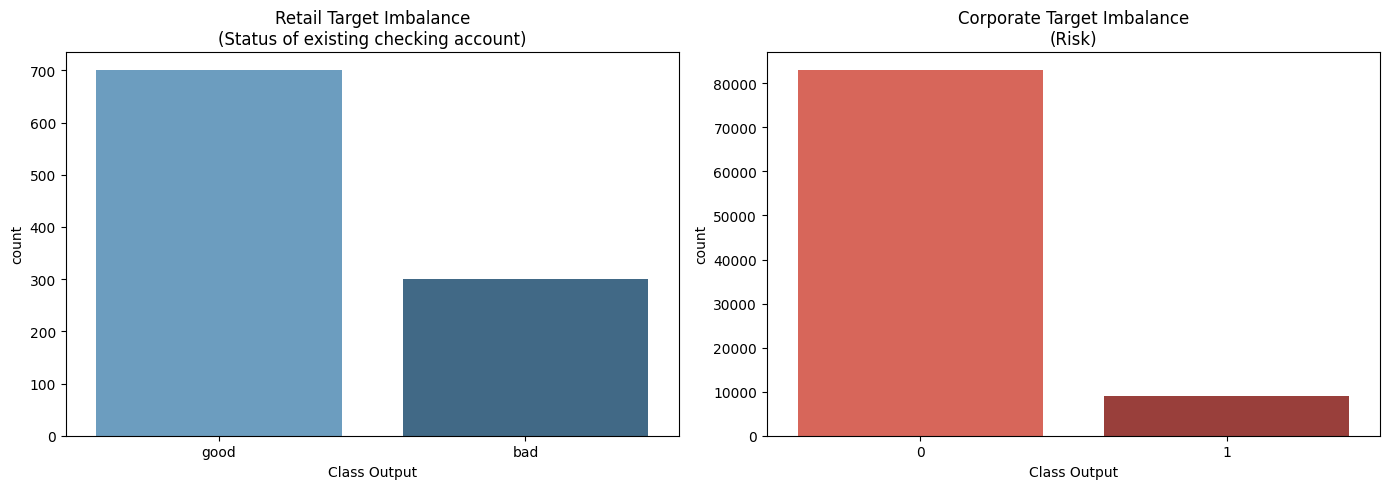


=== IMBALANCE RATIOS ===
Retail Dataset (Status of existing checking account):
Status of existing checking account
good    70.0
bad     30.0
Name: proportion, dtype: float64

Corporate Dataset (Risk):
Risk
0    90.1
1     9.9
Name: proportion, dtype: float64


In [2]:
# Retrieve a representative Retail target
retail_df = retail_data_dict['Credit Risk_Individual_Kaggel_26022026.csv']
target_col_retail = next((col for col in retail_df.columns if 'default' in col.lower() or 'target' in col.lower() or 'risk' in col.lower()), retail_df.columns[-1])

# Retrieve a representative Corporate target
corp_df = corporate_data_dict['Corporate Default Financial Dataset.csv']
target_col_corp = next((col for col in corp_df.columns if 'default' in col.lower() or 'target' in col.lower() or 'risk' in col.lower()), corp_df.columns[-1])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Retail Distribution Plot
plt_sns.countplot(data=retail_df, x=target_col_retail, ax=ax[0], palette='Blues_d')
ax[0].set_title(f'Retail Target Imbalance\n({target_col_retail})')
ax[0].set_xlabel('Class Output')

# Corporate Distribution Plot
plt_sns.countplot(data=corp_df, x=target_col_corp, ax=ax[1], palette='Reds_d')
ax[1].set_title(f'Corporate Target Imbalance\n({target_col_corp})')
ax[1].set_xlabel('Class Output')

plt.tight_layout()
plt.show()

# Calculate raw Imbalance Ratios
retail_ratio = retail_df[target_col_retail].value_counts(normalize=True).round(3) * 100
corp_ratio = corp_df[target_col_corp].value_counts(normalize=True).round(3) * 100

print("\n=== IMBALANCE RATIOS ===")
print(f"Retail Dataset ({target_col_retail}):\n{retail_ratio}\n")
print(f"Corporate Dataset ({target_col_corp}):\n{corp_ratio}")

## Step 3: Missing Data Topography (Corporate Track)
As noted in our Notebook 01 key findings, the Retail track displayed zero missing values, but the Corporate track exhibited significant sparsity. Understanding *how* these variables are missing is just as critical as knowing *how many* are missing. Utilizing the `missingno` matrix visualization allows us to detect underlying patterns in missingness—whether values are missing completely at random (MCAR) or missing systematically due to underlying sub-structures.

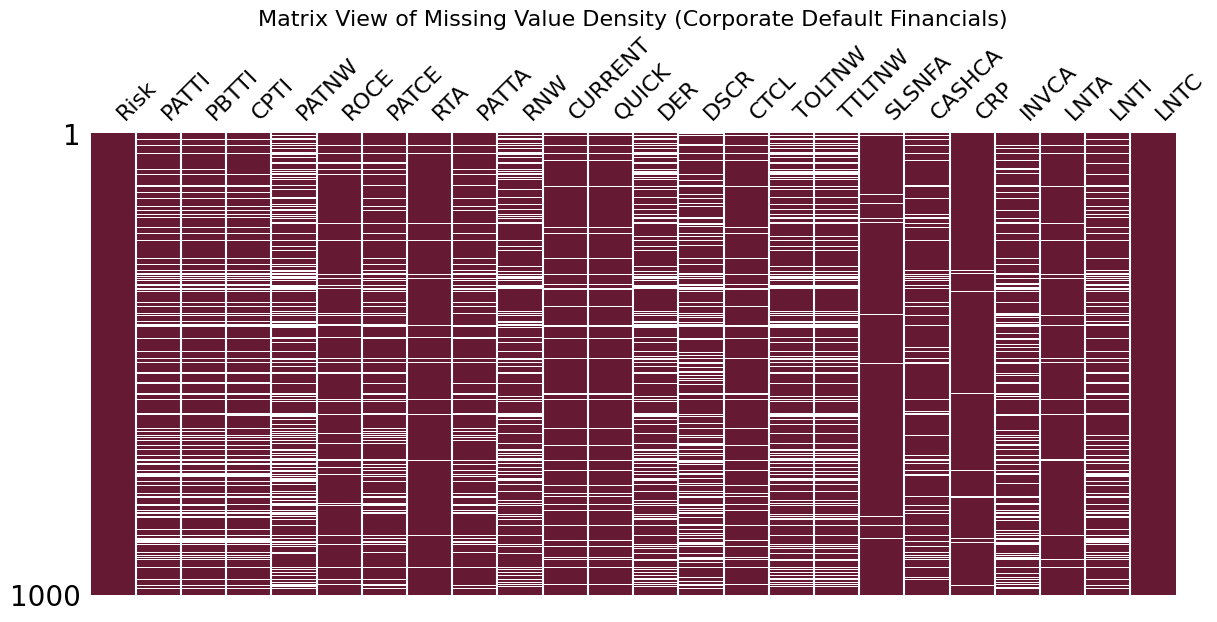

In [3]:
# Visualize sparsity density and structural gaps in the Corporate dataset
msno.matrix(corp_df.sample(min(1000, len(corp_df))), figsize=(14, 6), color=(0.4, 0.1, 0.2), sparkline=False)
plt.title("Matrix View of Missing Value Density (Corporate Default Financials)", fontsize=16)
plt.show()

## Step 4: Correlation & Multicollinearity Analysis
**Multicollinearity** occurs when two or more independent variables in our model are highly linearly related. In financial data, this is exceptionally common. Multicollinearity is intensely problematic for credit risk models as it wildly inflates coefficient variance, destroying interpretability and making models prone to overfitting. 

We generate a correlation heatmap restricted to the lower triangle to systematically identify redundant corporate features.

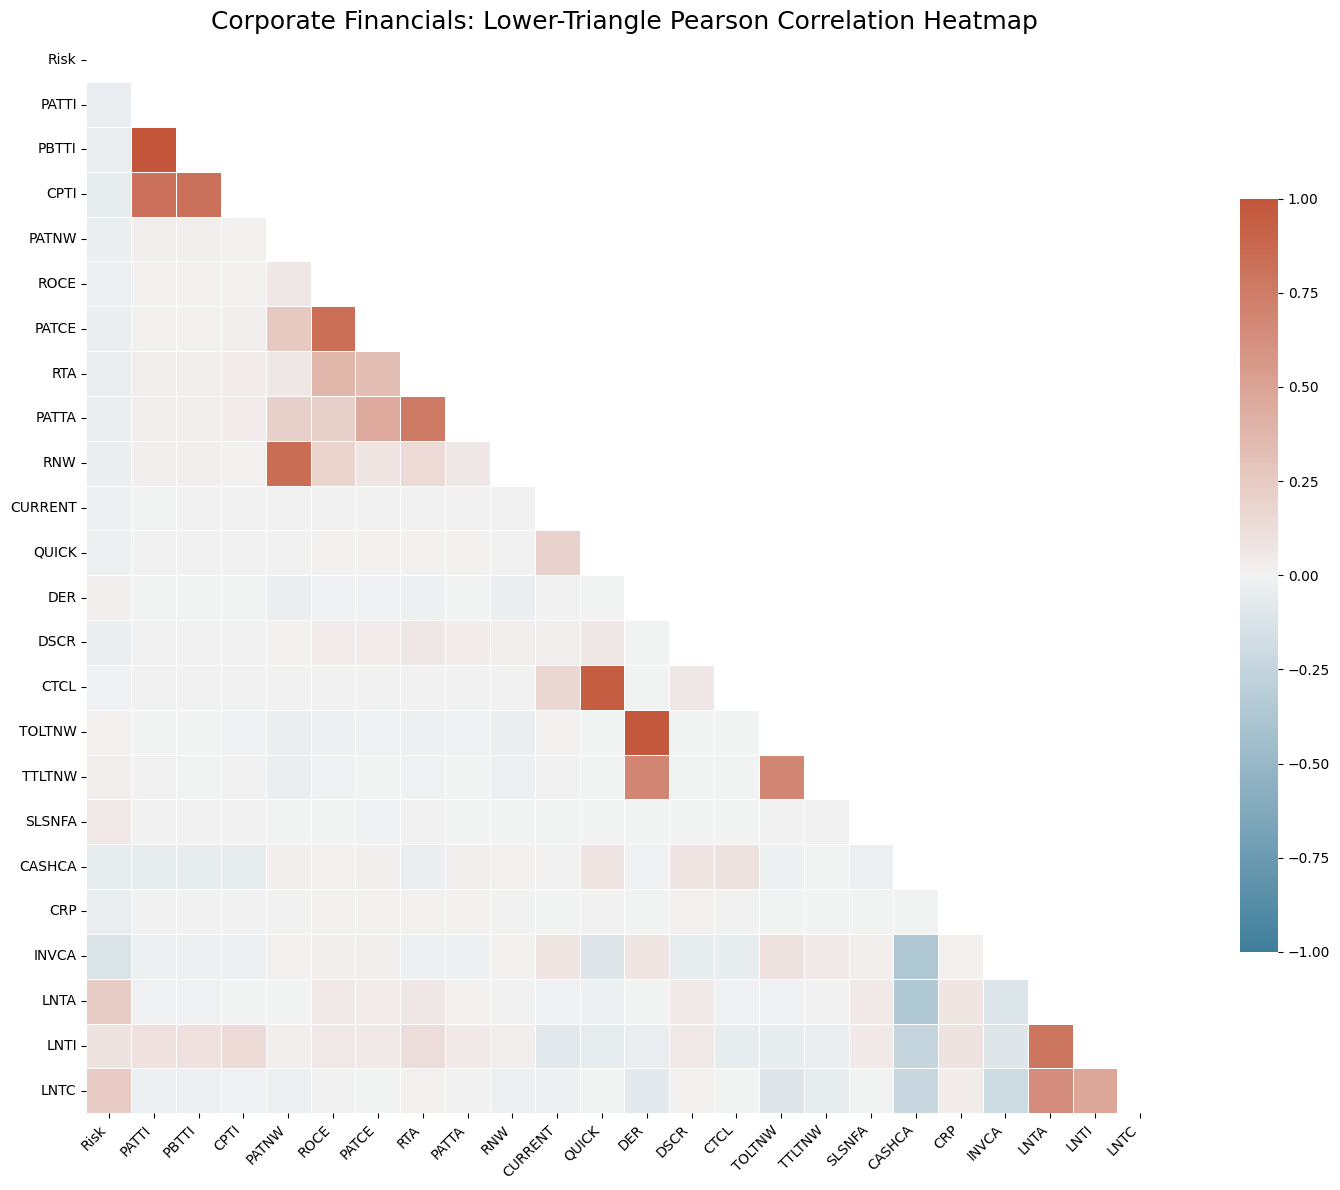

In [4]:
# Select strictly numerical features for the correlation matrix
numerical_corp = corp_df.select_dtypes(include=[np.number])

# Compute the correlation matrix calculation
corr = numerical_corp.corr()

# Generate a structural academic mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib academic figure
f, ax = plt.subplots(figsize=(16, 12))

# Generate a custom diverging colormap (Red to Blue)
cmap = plt_sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct academic aspect ratio
plt_sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .7})

plt.title("Corporate Financials: Lower-Triangle Pearson Correlation Heatmap", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Findings
*Research Progress & Preliminary EDA Results:*
- **Class Imbalance Severity:** Identified severe imbalance in the **Corporate Track (90.1% / 9.9%)** and significant imbalance in the **Retail Track (70% / 30%)**. This confirms the necessity for synthetic balancing (SMOTE) or adjusted loss functions in Notebook 03.
- **Missing At Random (MAR) Testing:** The matrix view confirms structural sparsity in corporate track indicators. Pattern analysis suggests MAR/MNAR clusters, requiring advanced iterative imputation (e.g., MICE) to avoid bias.
- **Multicollinearity Redundancies:** The Pearson matrix revealed significant inter-correlation clusters (>0.85) among financial health ratios. These redundant dimensions will be addressed via VIF screening and PCA to ensure stable model coefficients.


---
### End of Notebook 02 — Exploratory Data Analysis & Statistical Profiling

**Outputs produced:**
- `None` — Visualizations and exploratory matrices mapped to notebook outputs only.

**Next step → Notebook 03:** Feature Preprocessing & Engineering.

<div align="center"><sub>END OF NOTEBOOK 02</sub></div>